# eigenfaces: class dataset

same pipeline as the olivetti notebook, but applied to our own photos. 26 people, 3 images each.

since we only have 3 images per person, we use **leave-one-out**: 2 images per person go to training, 1 to testing.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.decomposition import PCA

IMG_SIZE = (64, 64)
DATASET_PATH = "class_pictures"

def load_dataset(root):
    X, y, label_map = [], [], {}
    for idx, person in enumerate(sorted(os.listdir(root))):
        person_dir = os.path.join(root, person)
        if not os.path.isdir(person_dir):
            continue
        label_map[idx] = person
        for fname in sorted(os.listdir(person_dir)):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            img = Image.open(os.path.join(person_dir, fname)).convert("L")
            img = img.resize(IMG_SIZE)
            X.append(np.array(img).flatten() / 255.0)
            y.append(idx)
    return np.array(X), np.array(y), label_map

X, y, label_map = load_dataset(DATASET_PATH)
print(f"loaded: {X.shape}  |  people: {len(label_map)}")

loaded: (78, 4096)  |  people: 26


## 1. explore the data

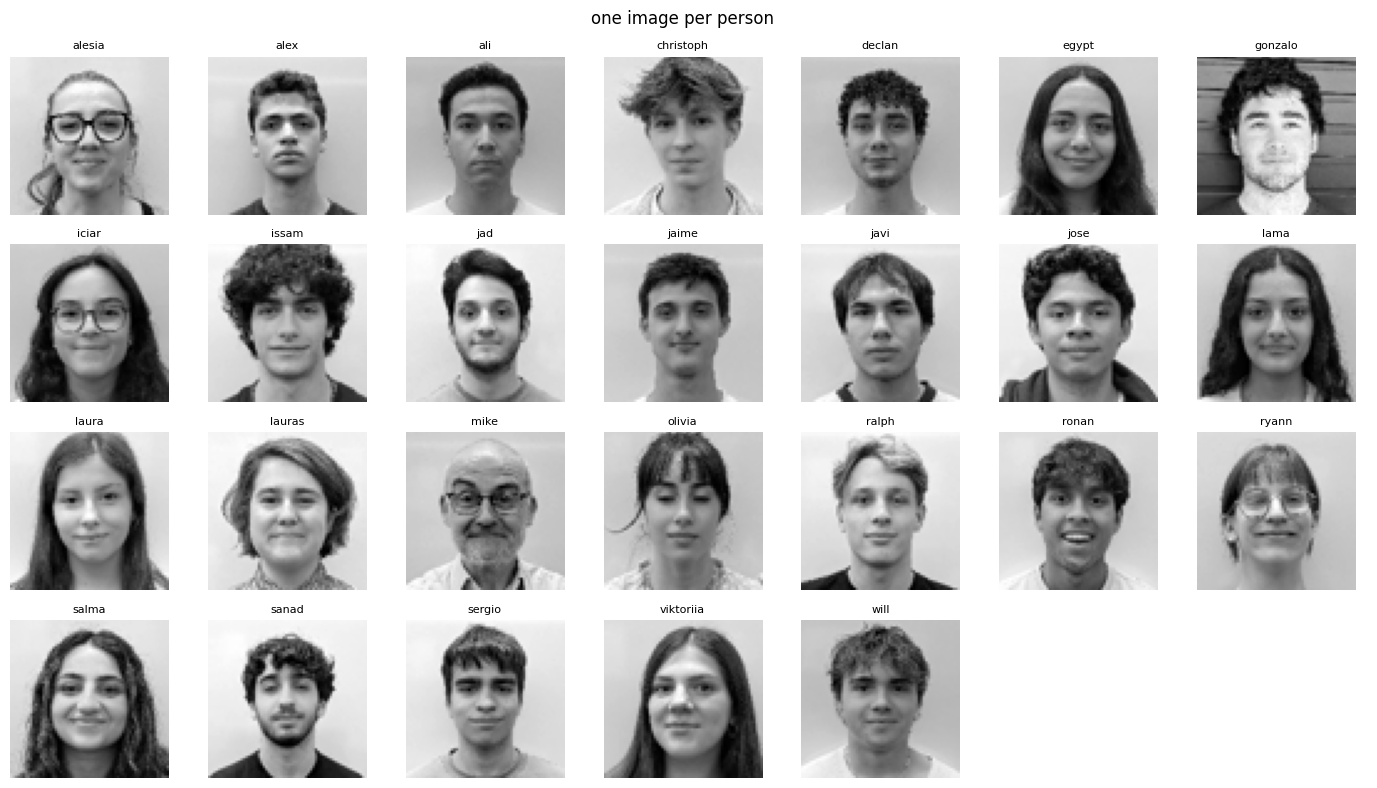

In [22]:
n_people = len(label_map)
fig, axes = plt.subplots(4, 7, figsize=(14, 8))
for i, ax in enumerate(axes.flat):
    if i >= n_people:
        ax.axis("off")
        continue
    # show first image of each person
    person_idx = np.where(y == i)[0][0]
    ax.imshow(X[person_idx].reshape(64, 64), cmap="gray")
    ax.set_title(label_map[i], fontsize=8)
    ax.axis("off")
plt.suptitle("one image per person")
plt.tight_layout()
plt.show()

## 2. leave-one-out split

with only 3 images per person, a random split would give some people 0 test images. instead we take the last image of each person as the test sample, and use the first 2 for training.

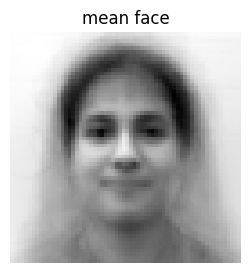

train: (52, 4096)  |  test: (26, 4096)


In [23]:
train_idx, test_idx = [], []

for person_id in np.unique(y):
    idxs = np.where(y == person_id)[0]
    train_idx.extend(idxs[:-1])  # first 2
    test_idx.append(idxs[-1])    # last 1

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

mean_face = X_train.mean(axis=0)
X_train_c = X_train - mean_face
X_test_c  = X_test  - mean_face

plt.figure(figsize=(3, 3))
plt.imshow(mean_face.reshape(64, 64), cmap="gray")
plt.title("mean face")
plt.axis("off")
plt.show()

print(f"train: {X_train.shape}  |  test: {X_test.shape}")

## 3. pca — eigenfaces

with only 52 training images, we cap $k$ at 50 (can't have more components than samples).

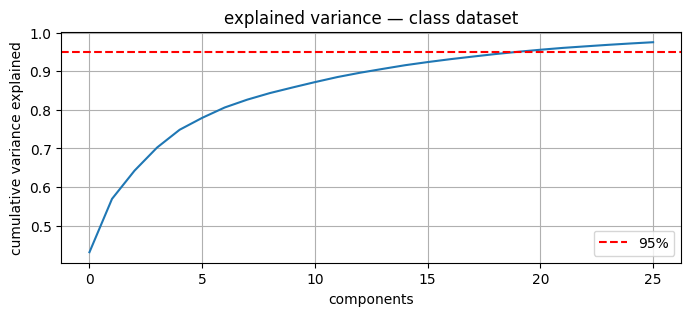

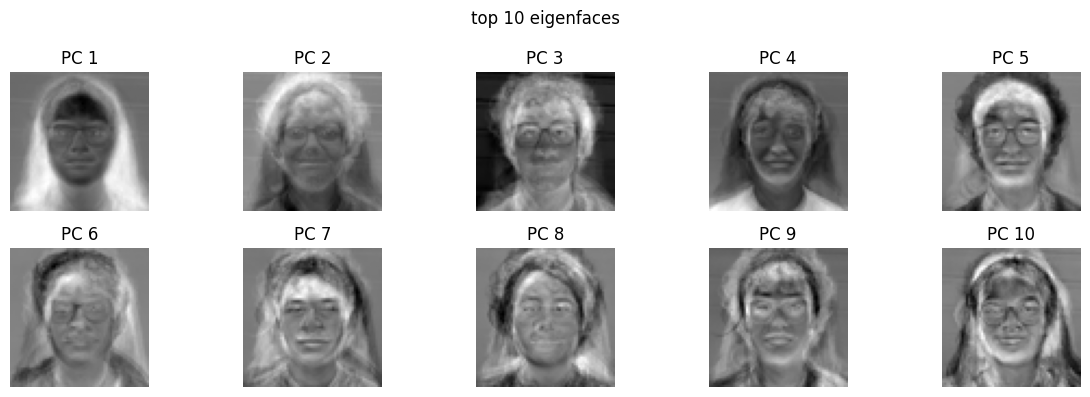

In [24]:
K = 26  # sensible cap for this dataset size

pca = PCA(n_components=K, svd_solver="randomized", whiten=False)
pca.fit(X_train_c)
eigenfaces = pca.components_

plt.figure(figsize=(8, 3))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(0.95, color="red", linestyle="--", label="95%")
plt.xlabel("components")
plt.ylabel("cumulative variance explained")
plt.title("explained variance — class dataset")
plt.legend()
plt.grid(True)
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces[i].reshape(64, 64), cmap="gray")
    ax.set_title(f"PC {i+1}")
    ax.axis("off")
plt.suptitle("top 10 eigenfaces")
plt.tight_layout()
plt.show()

## 4. face reconstruction

how well can we reconstruct a classmate's face from $k$ eigenfaces?

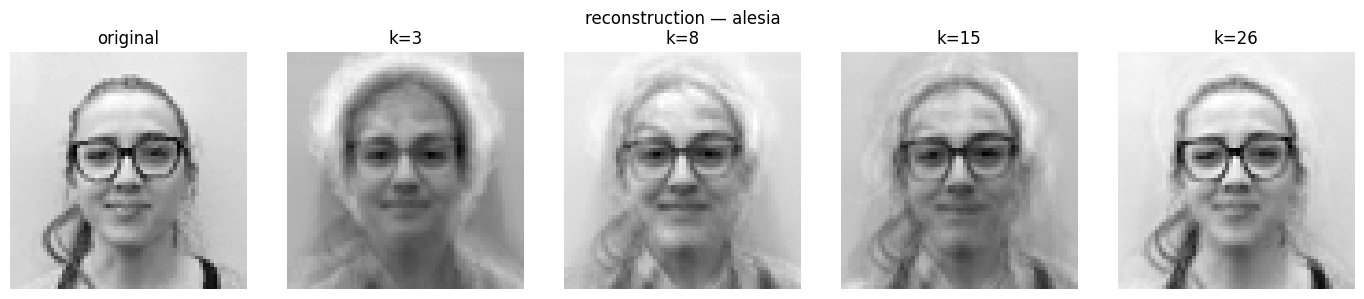

In [25]:
def reconstruct(X_c, components, mean):
    weights = X_c @ components.T
    return weights @ components + mean

k_show = [3, 8, 15, 26]
sample_c, sample_orig = X_test_c[[0]], X_test[0]

fig, axes = plt.subplots(1, len(k_show)+1, figsize=(14, 3))
axes[0].imshow(sample_orig.reshape(64, 64), cmap="gray")
axes[0].set_title("original")
axes[0].axis("off")

for ax, k_val in zip(axes[1:], k_show):
    rec = reconstruct(sample_c, eigenfaces[:k_val], mean_face)
    ax.imshow(rec.reshape(64, 64), cmap="gray")
    ax.set_title(f"k={k_val}")
    ax.axis("off")

plt.suptitle(f"reconstruction — {label_map[y_test[0]]}")
plt.tight_layout()
plt.show()

## 5. face recognition

project each test image into eigenspace and find the nearest training face.

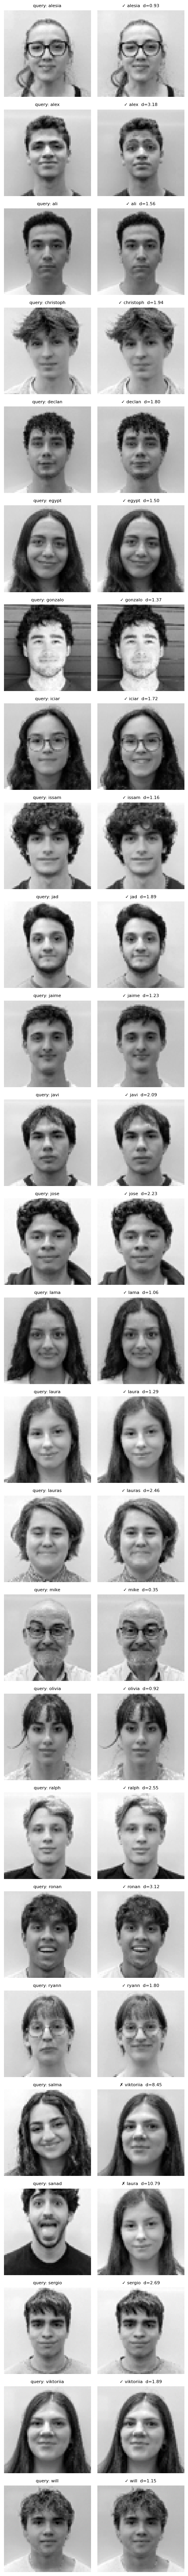

accuracy: 92.31%  (24/26 correct)


In [26]:
train_weights = X_train_c @ eigenfaces.T

def recognize(query_c):
    dists = np.linalg.norm(train_weights - (query_c @ eigenfaces.T), axis=1)
    idx = np.argmin(dists)
    return y_train[idx], dists[idx], idx

# show all test results
fig, axes = plt.subplots(len(y_test), 2, figsize=(5, len(y_test) * 2.5))
for row, i in enumerate(range(len(X_test_c))):
    pred, dist, match_idx = recognize(X_test_c[[i]])
    true_lbl = y_test[i]
    mark = "✓" if pred == true_lbl else "✗"

    axes[row, 0].imshow(X_test[i].reshape(64, 64), cmap="gray")
    axes[row, 0].set_title(f"query: {label_map[true_lbl]}", fontsize=8)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(X_train[match_idx].reshape(64, 64), cmap="gray")
    axes[row, 1].set_title(f"{mark} {label_map[pred]}  d={dist:.2f}", fontsize=8)
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

preds = [recognize(X_test_c[[i]])[0] for i in range(len(X_test_c))]
accuracy = np.mean(np.array(preds) == y_test)
print(f"accuracy: {accuracy:.2%}  ({int(accuracy*len(y_test))}/{len(y_test)} correct)")  

## 6. unknown face detection

we test whether the system correctly rejects someone who is not in the training set — in this case, a celebrity image that no one in the class resembles.

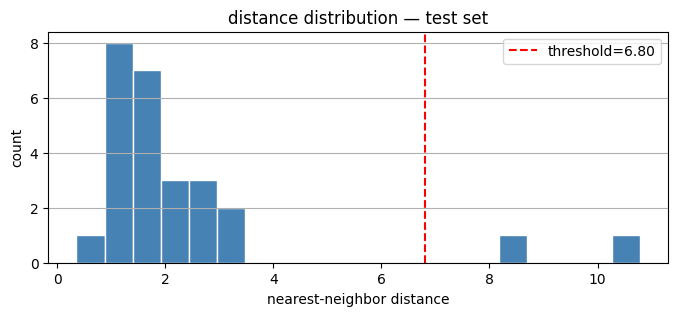

unknown image → 'unknown'  (dist=11.21, threshold=6.80)


In [27]:
distances_test = np.array([
    np.linalg.norm(train_weights - (X_test_c[[i]] @ eigenfaces.T), axis=1).min()
    for i in range(len(X_test_c))
])

threshold = distances_test.mean() + 2 * distances_test.std()

plt.figure(figsize=(8, 3))
plt.hist(distances_test, bins=20, color="steelblue", edgecolor="white")
plt.axvline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.2f}")
plt.xlabel("nearest-neighbor distance")
plt.ylabel("count")
plt.title("distance distribution — test set")
plt.legend()
plt.grid(True, axis="y")
plt.show()

# test with random noise as a stand-in for an unknown person
rng = np.random.default_rng(0)
unknown_c = rng.random((1, 4096)) - mean_face
dist = np.linalg.norm(train_weights - (unknown_c @ eigenfaces.T), axis=1).min()
result = "unknown" if dist > threshold else "known"
print(f"unknown image → '{result}'  (dist={dist:.2f}, threshold={threshold:.2f})")